热力图实验 g-beta, 在不同lambda1下

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. 辅助函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    """
    计算激活因子 epsilon_i:
    """
    p_A = states[:, 1] + states[:, 2] + states[:, 4]  # 取 AS + AI + AR 作为有意识水平
    epsilon = np.where(p_A > alpha, epsilon0, 0.0)
    return epsilon


def compute_effective_awareness(n, states, g_i, R):
    """
    计算每个中转站 j 的过客有效意识比例 tilde_p_j^A(t):
    """
    N = len(n)
    M = R.shape[1]
    n_out = n * g_i  
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        numerator = 0.0  # 分子
        denominator = 0.0 # 分母
        for i in range(N):
            flow = n_out[i] * R[i, j]
            numerator += flow * p_A_res[i]
            denominator += flow
        tilde_p_A[j] = numerator / denominator if denominator > 0 else 0.0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):
    """
    计算每个居住点 i 的意识转换概率 r_i:
    """
    N, M = R.shape
    
    # 生成信息层二值矩阵 A
    A = (R > 0).astype(int)  # 直接根据物理层权重是否非零生成二值矩阵
    
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            # 只有当物理层存在连接时（R[i,j] > 0），信息层才有边（A[i,j]=1）
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    """
    计算居住点内部的感染概率：
    """
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    # p_I = np.clip(states[:, 2], 0, 1)  # 确保 p_I ∈ [0,1]
    # 采用 np.power 计算 (1 - lambda * p_I)^(n_remain)
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    """
    计算中转站层面的感染概率：
    """
    N, M = R.shape
    M_U = np.zeros(M)
    M_A = np.zeros(M)
    for j in range(M):
        sum_U = 1.0
        sum_A = 1.0
        for k in range(N):
            n_to_j = n[k] * g_i[k] * R[k, j]
            p_I = states[k, 2]
            sum_U *= np.power(1 - beta_U * p_I, n_to_j)
            sum_A *= np.power(1 - beta_A * p_I, n_to_j)
        M_U[j] = 1 - sum_U
        M_A[j] = 1 - sum_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    """
    计算每个居住点 i 的总体感染概率：
    """
    N, M = R.shape
    Q_U = np.zeros(N)
    Q_A = np.zeros(N)
    for i in range(N):
        sum_MU = np.sum(R[i, :] * M_U)
        sum_MA = np.sum(R[i, :] * M_A)
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * sum_MU
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * sum_MA
    return Q_U, Q_A


def update_states(states, r, Q_U, Q_A, mu1, mu2):
    """
    根据状态更新公式更新居住点内各状态比例：
    """
    new_states = np.zeros_like(states)
    US = states[:, 0]
    AS = states[:, 1]
    AI = states[:, 2]
    UR = states[:, 3]
    AR = states[:, 4]
    
    new_states[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new_states[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new_states[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new_states[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new_states[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r

    # 归一化每个居住点的状态比例
    row_sums = new_states.sum(axis=1)
    row_sums[row_sums == 0] = 1e-10  # 避免除零
    new_states = new_states / row_sums[:, None]
    return new_states


def update_population(n, states, g_i, epsilon, R, T):
    """
    更新人口分布，仅通过 T 矩阵控制返回比例(无需 gamma_j)
    """
    N, M = R.shape
    F = n * g_i * epsilon

    # 剩余人口和状态
    X = states * n[:, None]
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 计算中转站流入人口
    m = np.zeros(M)
    m_X = np.zeros((M, 5))
    for j in range(M):
        for i in range(N):
            flow = n[i] * g_i[i] * epsilon[i] * R[i, j]
            m[j] += flow
            m_X[j] += X[i] * g_i[i] * epsilon[i] * R[i, j]

    # 计算返回人口（直接使用 T 矩阵）
    flow_return = np.zeros(N)
    flow_return_X = np.zeros((N, 5))
    for j in range(M):
          for i in range(N):
              flow_return[i] += m[j] * T[i, j]
              flow_return_X[i] +=  m_X[j]  * T[i, j]

    # 更新人口和状态
    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states


# ---------------------------
# 2. 主仿真流程
# ---------------------------
def main_simulation(Time, N, M, params):
    """
    主仿真流程
    """
    lambda1 = params['lambda1']
    mu1 = params['mu1']
    mu2 = params['mu2']
    beta_U = params['beta_U']
    beta_A = params['beta_A']
    g_global = params['g']
    # gamma_global = params['gamma']
    epsilon0 = params['epsilon0']
    alpha = params['alpha']
    theta = params['theta']
    # kappa = params['kappa']

    # 居住点特异性迁移率和返回率（这里使用常数，可扩展为数组）
    g_i = np.full(N, theta * g_global)
    # gamma_i = np.full(N, kappa * gamma_global)
    
    # 设置返回率 gamma_j = 1(不一定)
    # gamma_j = np.full(M, kappa * gamma_global)  # 每个中转站有独立的返回率

    # 初始化各居住点人口（例如每个 500 人）和状态比例（US, AS, AI, UR, AR）
    n = np.full(N, 200.0)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99  # US
    states[:, 2] = 0.01  # AI
    states = states / states.sum(axis=1, keepdims=True)
    
    # 初始化居住点与中转站之间的权重矩阵 R (N x M)，对称归一化：每个居住点行和为 1
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)  # 行归一化（迁移）
    T = w / w.sum(axis=0, keepdims=True)  # 列归一化（返回）

    # 用于记录历史数据
    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))
    
    for t in range(Time):
        state_history[t] = states
        pop_history[t] = n
        
        # 1. 计算当前居住点局部有意识比例 p^A = AS + AI + AR
        # 2. 计算激活因子 epsilon: 若 p^A > alpha 则 epsilon = epsilon0，否则 0
        epsilon = compute_epsilon(states, alpha, epsilon0)
        
        # 2.5. 更新居住点的人口及状态（基于 MIR 过程） n_new为更新后的居住点人口数，states_new为更新后的居住点状态比例
        n_new, states_new = update_population(n, states, g_i, epsilon, R, T)

        # 3. 计算中转站的过客有效意识比例 tilde_p^A
        tilde_p_A = compute_effective_awareness(n, states_new, g_i, R)
        # 4. 计算居住点的意识转换概率 r
        r = compute_awareness_conversion(R, lambda1, tilde_p_A)
        # print('t', t, 'r', r)
        
        # 5. 计算居住点内部感染风险
        N_U, N_A = compute_infection_residence(n, states_new, g_i, beta_U, beta_A)
        # 6. 计算中转站层面的感染风险
        M_U, M_A = compute_infection_transit(n, states_new, g_i, R, beta_U, beta_A)
        # 7. 综合计算每个居住点的总体感染概率 Q
        Q_U, Q_A = compute_overall_infection(n, states_new, g_i, R, N_U, N_A, M_U, M_A)
        
        # 8. 更新居住点内部的疾病/意识状态
        states = update_states(states_new, r, Q_U, Q_A, mu1, mu2)
        n = n_new

        
    return state_history, pop_history


epsilon0=0.9扫描: 100%|██████████| 19/19 [02:26<00:00,  7.71s/it]


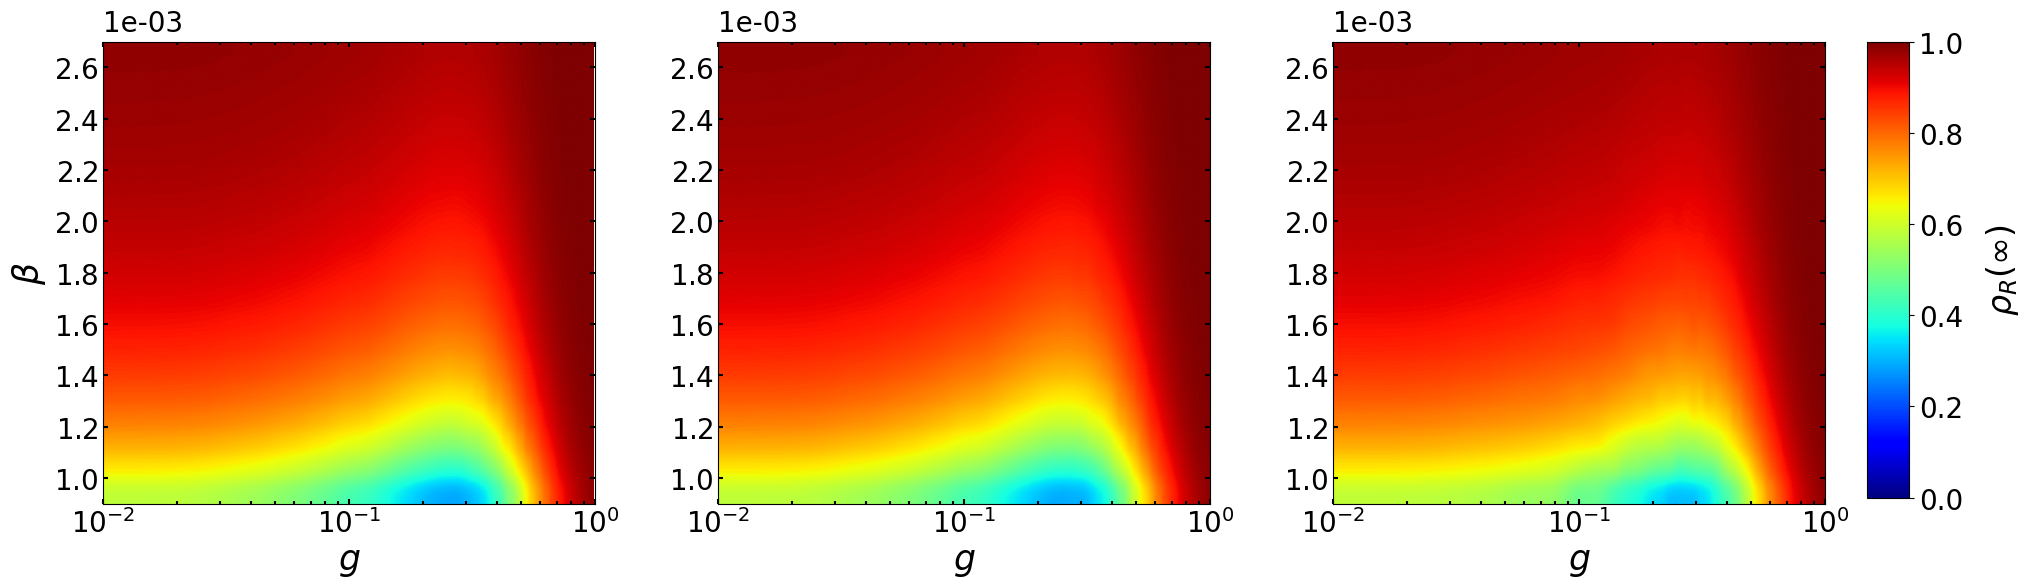

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

# 参数设置
num_simulations = 2 
Time = 150            
N = 15                
M = 5                 
sigma = 0.5           

# 参数范围
beta_U_values = np.arange(0.0009, 0.0028, 0.0001)
g_values = np.concatenate([
    np.arange(0.01, 0.1, 0.02),
    np.arange(0.1, 1.01, 0.02)
])

# 基础参数配置
base_params = {
    'mu1': 0.15, 'mu2': 0.1, 'lambda1': 0.2,
    'beta_U': 0.001, 'beta_A': 0.0005, 'g': 0.8,
    'alpha': 0.3, 'theta': 1, 'kappa': 1
}

# 仿真函数
def simulate_steady_state(params):
    state_history, _ = main_simulation(Time, N, M, params)
    steady_state = state_history[-1]
    return np.mean(steady_state[:, 3] + steady_state[:, 4])

# 创建3个子图，调整宽度以容纳colorbar
fig, axes = plt.subplots(1, 3, figsize=(21, 6), gridspec_kw={'width_ratios': [1, 1, 1]})
epsilon_values = [0, 0.01, 0.9]

for idx, epsilon0 in enumerate(epsilon_values):
    # 初始化结果矩阵
    steady_R_betaU_g = np.zeros((len(beta_U_values), len(g_values), num_simulations))
    
    # 更新当前lambda1值
    current_params = base_params.copy()
    current_params['epsilon0'] = epsilon0
    
    # (β_U, g)扫描
    for i, beta_U in enumerate(tqdm(beta_U_values, desc=f"epsilon0={epsilon0}扫描")):
        for j, g in enumerate(g_values):
            params = current_params.copy()
            params['beta_U'] = beta_U
            params['beta_A'] = sigma * beta_U
            params['g'] = g
            
            results = Parallel(n_jobs=-1)(
                delayed(simulate_steady_state)(params)
                for _ in range(num_simulations)
            )
            steady_R_betaU_g[i,j,:] = results
    
    # 计算均值并绘制热力图
    mean_R = np.mean(steady_R_betaU_g, axis=2)
    im = axes[idx].imshow(mean_R, cmap='jet', interpolation='gaussian',
                         extent=[g_values.min(), g_values.max(), beta_U_values.min(), beta_U_values.max()],
                         origin='lower', aspect='auto',
                         vmin=0, vmax=1)  # 固定颜色范围
    
    # 子图装饰（保持个性化设置）
    axes[idx].set_xscale("log")
    # axes[idx].set_title(f'λ1 = {lambda1}', fontsize=20, pad=10)
    axes[idx].set_xlabel(r'$g$', fontsize=25)
    if idx == 0:
        axes[idx].set_ylabel(r'$\beta$', fontsize=25)
    
    # 设置刻度（保持与示例一致）
    axes[idx].set_xticks([0.01, 0.1, 1])
    axes[idx].tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
    width=1.5,          # 刻度宽度
    )

    axes[idx].set_xticklabels(["$10^{-2}$", "$10^{-1}$", "$10^{0}$"], fontsize=20)
    axes[idx].set_yticks([0.001, 0.0012, 0.0014, 0.0016, 0.0018, 0.0020, 0.0022, 0.0024, 0.0026 ])
    axes[idx].set_yticklabels([r'$1.0$', r'$1.2$', r'$1.4$', r'$1.6$', r'$1.8$', r'$2.0$', r'$2.2$', r'$2.4$', r'$2.6$'], fontsize='20')
    
    # 添加y轴顶部的指数标注
    axes[idx].text(0.0, 1.01, '1e-03', fontsize=20, 
                  verticalalignment='bottom', 
                  transform=axes[idx].transAxes)

# 添加共享colorbar（放置在图外右侧）
cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.76])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\rho_R(\infty)$', fontsize=24, labelpad=15)
cbar.ax.tick_params(labelsize=20)

# 调整子图间距
plt.subplots_adjust(left=0.08, right=0.9, wspace=0.25)

plt.show()